In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
data=pd.read_csv('/content/Telco-Customer-Churn.csv')

In [61]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [62]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [64]:
data['TotalCharges'].isnull().sum()

np.int64(0)

In [65]:
data['TotalCharges'].dtype

dtype('O')

In [66]:
data['TotalCharges']= pd.to_numeric(data['TotalCharges'],errors='coerce')

In [67]:
data['TotalCharges'].dtype

dtype('float64')

In [68]:
data['Churn']

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [69]:
data['Churn']= data['Churn'].map({'Yes':1,'No':0})

In [70]:
data['Churn']

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


# Q).Are new customer churning more???
tenure = number of months customer has stayed with the company.

we create coustomers into category like (1-2 yr, 3-4yr: bins)

In [71]:
bins = [0, 12, 24, 48, 72] # 0-12 months =1 yr, 12-24month=2 yr .....
labels = ["0-1 year", "1-2 years", "2-4 years", "4-6 years"]
data['tenure_grp'] = pd.cut(data['tenure'], bins=bins, labels=labels) #pd.cut()-> chceks each cus tenure and assigns it to a grp


In [73]:
data[["tenure", "tenure_grp"]].head()


,tenure,tenure_grp
0,1,0-1 year
1,34,2-4 years
2,2,0-1 year
3,45,2-4 years
4,2,0-1 year


In [74]:
data['tenure'].head()

,tenure
0,1
1,34
2,2
3,45
4,2


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7032 non-null   category
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [76]:
data["Estimated_LTV"] = data["MonthlyCharges"] * data["tenure"] #This helps in revenue analysis, If customer pays ₹1000 monthly for 12 months
# → LTV = ₹12,000
data["Estimated_LTV"]


,Estimated_LTV
0,29.85
1,1936.30
2,107.70
3,1903.50
4,141.40
...,...
7038,2035.20
7039,7430.40
7040,325.60
7041,297.60


In [81]:
total_customers = len(data)
churn_rate = data["Churn"].mean()
avg_tenure = data["tenure"].mean()
avg_monthly = data["MonthlyCharges"].mean()

print("Total Customers:", total_customers)
print("Churn Rate:", round(churn_rate*100,2), "%")
print("Average Tenure:", round(avg_tenure,2))
print("Average Monthly Charges:", round(avg_monthly,2))


Total Customers: 7043
Churn Rate: 26.54 %
Average Tenure: 32.37
Average Monthly Charges: 64.76


# Exploratory Churn Analysis
Who is churning?

When are they churning?

Why are they churning?

In [82]:
data["Churn"].value_counts() # 0: not churning, 1: churning


,count
Churn,
0,5174
1,1869


In [83]:
churn_rate = data["Churn"].mean() # mean = sums of 1s / total cus
print("Overall Churn Rate:", round(churn_rate * 100, 2), "%")


Overall Churn Rate: 26.54 %


In [84]:
data.groupby("Contract")["Churn"].mean() * 100 #Are month-to-month customers leaving more??

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


Business Insight: Month-to-month customers are high risk.

Recommendation:Offer discount to convert them to yearly plans.

In [85]:
data.groupby("tenure_grp")["Churn"].mean() * 100

/tmp/ipython-input-1500385972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("tenure_grp")["Churn"].mean() * 100


,Churn
tenure_grp,
0-1 year,47.678161
1-2 years,28.710938
2-4 years,20.388959
4-6 years,9.513176


In [86]:
data.groupby("PaymentMethod")["Churn"].mean() * 100

,Churn
PaymentMethod,
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101
Electronic check,45.285412
Mailed check,19.106700


In [87]:
data.groupby("Churn")["Estimated_LTV"].mean()

,Estimated_LTV
Churn,
0,2549.770883
1,1531.608828


In [88]:
data.groupby("Churn")["MonthlyCharges"].mean()


,MonthlyCharges
Churn,
0,61.265124
1,74.441332


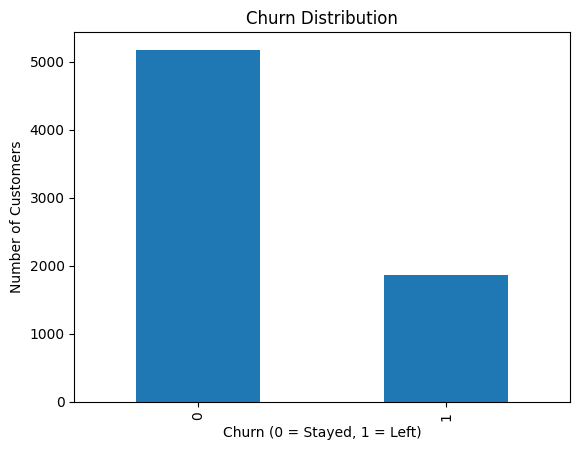

In [89]:
plt.figure()
data["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")
plt.show()


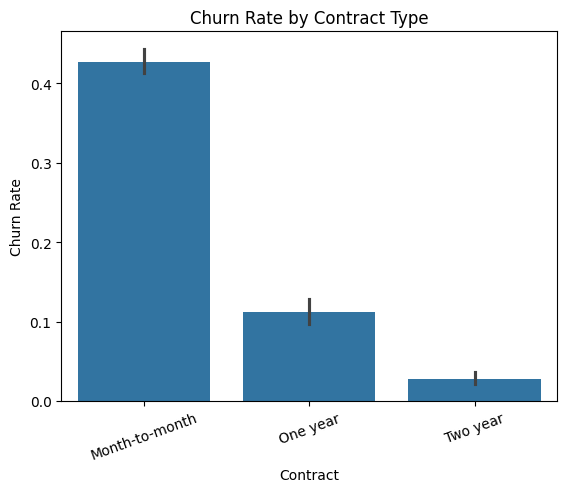

In [90]:
plt.figure()
sns.barplot(x="Contract", y="Churn", data=data)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()


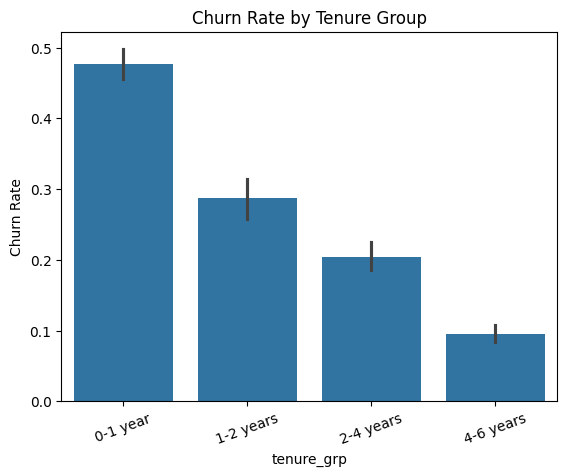

In [92]:
plt.figure()
sns.barplot(x="tenure_grp", y="Churn", data=data)
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()


In [95]:
data.to_csv("Cleaned_churn_data.csv")